В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
from sklearn.metrics import mean_squared_error

Метод МНК

In [40]:
medical_df = pd.read_csv('medical-charges.csv')
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [41]:
X = non_smoker_df['age'].values
y = non_smoker_df['charges'].values

In [42]:
X_with_intercept = np.c_[np.ones((X.shape[0], 1)), X]

In [43]:
def normal_equations(X,y):
    """Computes the closed-form solution to linear regression"""
    theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return theta

In [44]:
MNK_coefs = normal_equations(X_with_intercept, y)
MNK_coefs

array([-2091.42055657,   267.24891283])

In [45]:
predictions_MNK = np.dot(X_with_intercept, MNK_coefs)
predictions_MNK

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289], shape=(1064,))

In [98]:
rmse_mnk= np.sqrt(mean_squared_error(y, predictions_MNK))
print(f"RMSE: {rmse:.2f}")


RMSE: 4662.51


Градієнтний спуск


In [ ]:
# Перетворюємо X у двовимірний масив 
X_fbgd = non_smoker_df['age'].values.reshape(-1, 1)
y_fbgd = non_smoker_df['charges'].values

In [49]:
X_fbgd

array([[18],
       [28],
       [33],
       ...,
       [18],
       [18],
       [21]], shape=(1064, 1))

In [53]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    m, b = 0.0, 0.0  
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * X[:, 0] + b  
        error = y_pred - y
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, X[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

In [100]:
rmse_sgd = np.sqrt(mean_squared_error(y, predictions_fbgd_m2))
rmse_sgd

np.float64(4713.250582815521)

In [104]:
# 1. Тест для lr = 0.001 
m1, b1, err1 = full_batch_gradient_descent(X_fbgd, y_fbgd, lr=0.001, epochs=1000)
predictions_fbgd_m1 = m1 * X_fbgd[:, 0] + b1
rmse_m1 = np.sqrt(mean_squared_error(y, predictions_fbgd_m1))


print(f"Коефіцієнти (lr=0.001): m = {m1:.2f}, b = {b1:.2f}")
print(f"RMSE (0.001): {rmse_m1:.2f}")

/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:8: RuntimeWarning: overflow encountered in scalar add
  errors.append(sum(error**2))
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:8: RuntimeWarning: overflow encountered in square
  errors.append(sum(error**2))
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:9: RuntimeWarning: overflow encountered in dot
  m_gradient = (2/n) * np.dot(error, X[:, 0])
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


ValueError: Input contains NaN.

In [106]:
m1, b1, err1 = full_batch_gradient_descent(X_fbgd, y_fbgd, lr=0.001, epochs=1000)
predictions_fbgd_m1 = m1 * X_fbgd[:, 0] + b1

print(f"Коефіцієнти (lr=0.001): m = {m1:.2f}, b = {b1:.2f}")

Коефіцієнти (lr=0.001): m = nan, b = nan


/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:8: RuntimeWarning: overflow encountered in scalar add
  errors.append(sum(error**2))
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:8: RuntimeWarning: overflow encountered in square
  errors.append(sum(error**2))
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:9: RuntimeWarning: overflow encountered in dot
  m_gradient = (2/n) * np.dot(error, X[:, 0])
/var/folders/23/hq5l70qs1ll4j_wg3rzw4_th0000gn/T/ipykernel_8526/1789085075.py:11: RuntimeWarning: invalid value encountered in scalar subtract
  m = m - lr * m_gradient


In [103]:
# 2. Тест для lr = 0.0001
m2, b2, err2 = full_batch_gradient_descent(X_fbgd, y_fbgd, lr=0.0001, epochs=1000)
predictions_fbgd_m2 = m2 * X_fbgd[:, 0] + b2
rmse_m2 = np.sqrt(mean_squared_error(y, predictions_fbgd_m2))

# 3. Тест для lr = 0.00001
m3, b3, err3 = full_batch_gradient_descent(X_fbgd, y_fbgd, lr=0.00001, epochs=1000)
predictions_fbgd_m3 = m3 * X_fbgd[:, 0] + b3
rmse_m3 = np.sqrt(mean_squared_error(y, predictions_fbgd_m3))

print(f"Коефіцієнти (lr=0.0001): m = {m2:.2f}, b = {b2:.2f}")
print(f"Коефіцієнти (lr=0.00001): m = {m3:.2f}, b = {b3:.2f}")
print(f"RMSE (0.0001): {rmse_m2:.2f}")
print(f"RMSE (0.00001): {rmse_m3:.2f}")

Коефіцієнти (lr=0.0001): m = 221.10, b = -41.98
Коефіцієнти (lr=0.00001): m = 220.15, b = 0.21
RMSE (0.0001): 4713.25
RMSE (0.00001): 4715.35


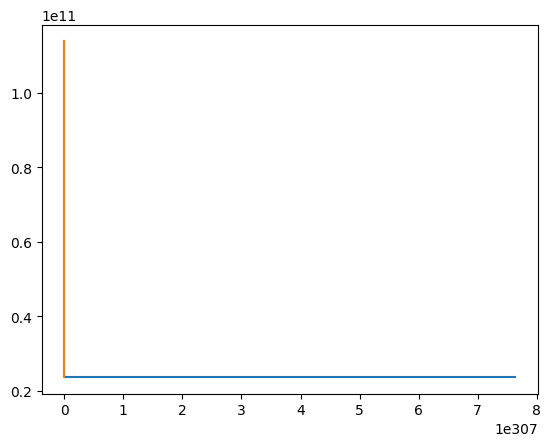

In [94]:
plt.plot(err1, err2, err3);

In [63]:
from sklearn.linear_model import LinearRegression

# Модель лінійної регресії засобами Scikit-learn (МНК)
lin_reg = LinearRegression()

In [65]:
X_sk = non_smoker_df['age'].to_frame() 
y_sk = non_smoker_df['charges']

In [68]:
lin_reg.fit(X_sk, y_sk)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
lin_reg.coef_, lin_reg.intercept_


(array([267.24891283]), np.float64(-2091.4205565650773))

In [71]:
predictions_sklearn = lin_reg.predict(X_sk)

In [85]:
rmse_sklearn = np.sqrt(mean_squared_error(y_sk, predictions_sklearn))
print('RMSE sklearn: ', rmse_sklearn)

RMSE sklearn:  4662.505766636395


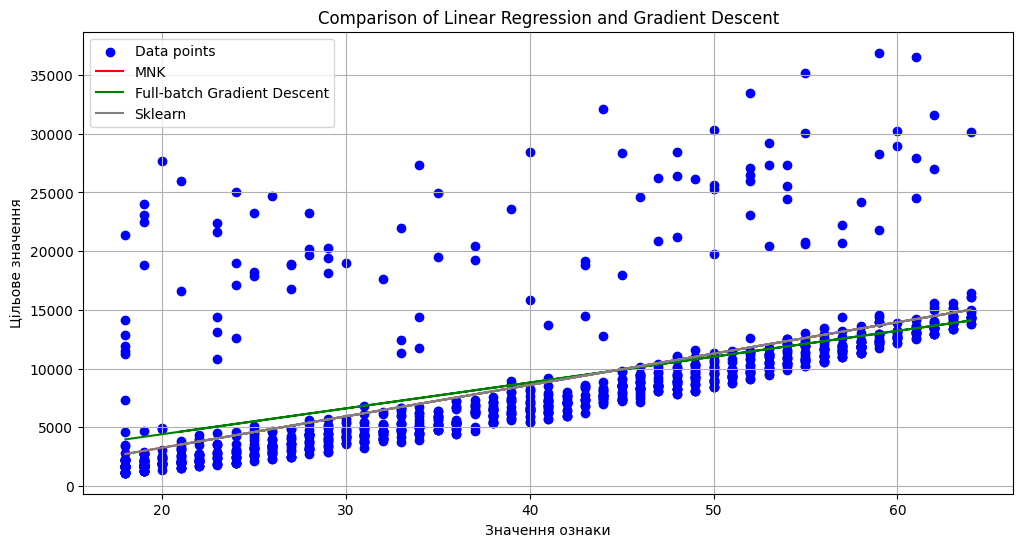

In [ ]:
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, predictions_MNK, color='red', label='MNK')
plt.plot(X, predictions_fbgd_m3, color='green', label='Full-batch Gradient Descent')
plt.plot(X, predictions_sklearn, color='grey', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Значення ознаки')
plt.ylabel('Цільове значення')
plt.legend()
plt.grid(True)
plt.show()

Всі три способи мають майже однаковий результат. А лінії за методами MNK та sklearn наклалися одна на одну. Модель добре побудувалася, лінії йдуть у тренді з даними

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [113]:
smoker_df = medical_df[medical_df.smoker == 'yes']

In [114]:
X_sk_smoker = smoker_df['age'].to_frame() 
y_sk_smoker = smoker_df['charges']

In [116]:
lin_reg = LinearRegression()

In [117]:
lin_reg.fit(X_sk_smoker, y_sk_smoker)
lin_reg.coef_, lin_reg.intercept_

predictions_sklearn_smoker = lin_reg.predict(X_sk_smoker)
rmse_sklearn_smoker = np.sqrt(mean_squared_error(y_sk_smoker, predictions_sklearn_smoker))
print('RMSE sklearn: ', rmse_sklearn_smoker)


RMSE sklearn:  10711.00334810241


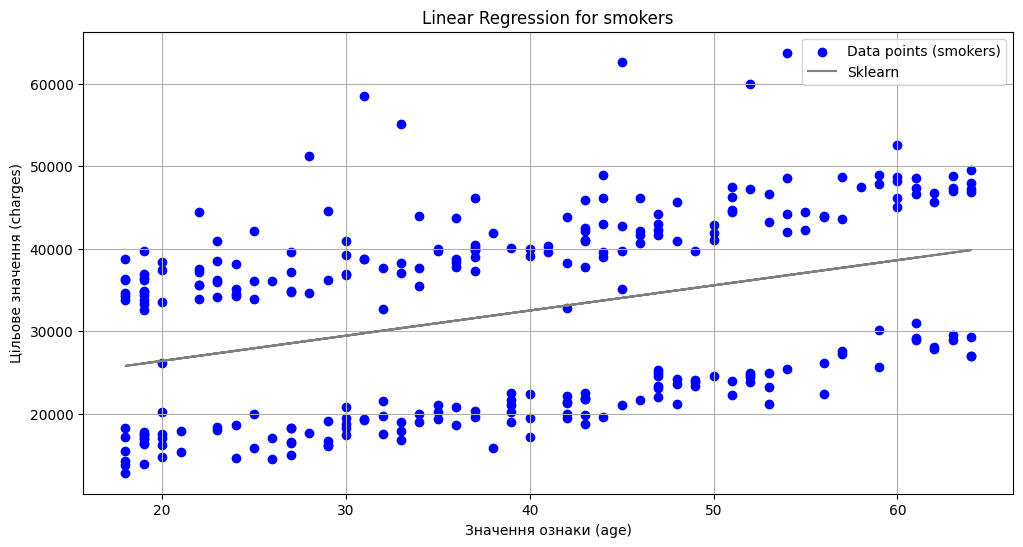

In [119]:
plt.figure(figsize=(12, 6))
plt.scatter(smoker_df["age"], smoker_df["charges"], color='blue', label='Data points (smokers)')
plt.plot(smoker_df["age"], predictions_sklearn_smoker, color='grey', label='Sklearn')
plt.title('Linear Regression for smokers')
plt.xlabel('Значення ознаки (age)')
plt.ylabel('Цільове значення (charges)')
plt.legend()
plt.grid(True)
plt.show()